In [1]:
import mpltex
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.cbook import get_sample_data
import pandas as pd
import numpy as np
import random, itertools, math, re, os
import csv
from collections import defaultdict
os.environ["PATH"] = "/Library/TeX/texbin:" + os.environ["PATH"]

In [2]:
plt.rcParams['pgf.texsystem'] = 'pdflatex'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

In [3]:
df = pd.read_csv('AB4_algo_timer_osf.csv')

# 计算单次SCFT耗时 (秒)
df['time_per_call'] = (df['scft_time_ms'] / df['ncalls']) / 1000

# 按算法名称分组，计算均值和标准差
grouped = df.groupby('updater_name').agg({
    'ratio': ['mean', 'std'],
    'time_per_call': ['mean', 'std']
})

# 平铺多级列名
grouped.columns = ['_'.join(col).strip() for col in grouped.columns.values]
grouped = grouped.reset_index()

# 自定义排序以保持逻辑分组 (Base, AA, OA, NA)
custom_order = ['SD', 'AA_SD', 'OA_SD', 'NA_SD', 
                'ETD', 'AA_ETD', 'OA_ETD', 'NA_ETD', 
                'SIS', 'AA_SIS', 'OA_SIS', 'NA_SIS']
grouped['updater_name'] = pd.Categorical(grouped['updater_name'], categories=custom_order, ordered=True)
grouped = grouped.sort_values('updater_name')

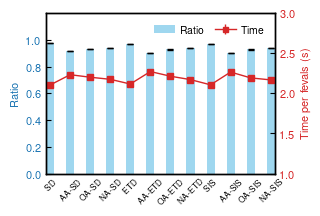

In [5]:
@mpltex.acs_decorator
def plot_performance_comparison():
    fig, ax1 = plt.subplots(1)
    linestyles = mpltex.linestyle_generator(lines=['-'], hollow_styles=[])
    linestyles_list = [next(linestyles) for _ in range(10)]

    # 1. 绘制柱状图 (Ratio) - 左侧坐标轴
    x = np.arange(len(grouped))
    width = 0.4
    bars = ax1.bar(x, grouped['ratio_mean'], width, yerr=grouped['ratio_std'], 
                capsize=2, label='Ratio', color='skyblue', alpha=0.8, edgecolor='none')

    ax1.set_ylabel('Ratio', color='tab:blue', fontsize=8)
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    # ax1.set_ylabel('Ratio', fontsize=8)
    ax1.tick_params(axis='y')
    ax1.set_xticks(x)
    ax1.tick_params(axis='x', labelsize=6, length=0)
    ax1.set_xticklabels(grouped['updater_name'].str.replace('_', '-', regex=False), rotation=45)
    # ax1.set_ylim(0, 1.4)  # 设置Ratio范围以便观察
    # ax1.set_yticks(np.arange(0, 1.4, 0.2))
    ax1.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0]) 
    # 依然保持 Y 轴视野到 1.4，以此保留柱子和顶部的空隙
    ax1.set_ylim(0, 1.2)

    # 2. 绘制折线图 (Time per call) - 右侧坐标轴
    ax2 = ax1.twinx()
    """
    line = ax2.errorbar(x, grouped['time_per_call_mean'], yerr=grouped['time_per_call_std'], 
                        fmt='-o', color='tab:red', capsize=4, label='Time', linewidth=1)
    """
    line = ax2.errorbar(x, grouped['time_per_call_mean'], yerr=grouped['time_per_call_std'], 
                        label='Time', **linestyles_list[1])

    # ax2.set_ylabel('Time per fevals (s)', fontsize=8)
    # ax2.tick_params(axis='y')
    ax2.set_ylabel('Time per fevals (s)', color='tab:red', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='tab:red')
    ax2.set_yticks(np.arange(1.0, 3.1, 0.5))

    # 添加标题和图例，横排显示
    # plt.title('Performance Comparison: Ratio vs. Time Cost per SCFT Step', fontsize=14)
    fig.legend(loc='upper right', bbox_to_anchor=(0.85, 0.92), ncol=2)

    plt.tight_layout()
    plt.savefig('scft_performance_comparison_noedge.png')
    plt.savefig('scft_performance_comparison_noedge.pdf')
    plt.show()

plot_performance_comparison()

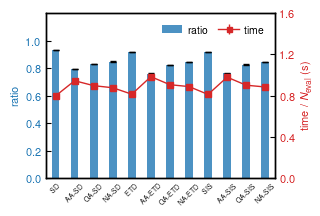

In [7]:
@mpltex.acs_decorator
def plot_performance_comparison_osf():
    fig, ax1 = plt.subplots(1)
    linestyles = mpltex.linestyle_generator(lines=['-'], hollow_styles=[])
    linestyles_list = [next(linestyles) for _ in range(10)]

    # 可选的配色方案，按需切换索引
    color_sets = [
        {'name': 'classic', 'bars': ('#1f77b4', '#6baed6'), 'line': '#d62728'},
        {'name': 'ink', 'bars': ('#0b3c5d', '#328cc1'), 'line': '#c70039'},
        {'name': 'slate', 'bars': ('#2a4d69', '#4b86b4'), 'line': '#e04f5f'}
    ]
    palette = color_sets[0]  # 修改此索引即可切换方案

    bar_color_primary, _ = palette['bars']
    line_color = palette['line']

    # 1. 绘制柱状图 (ratio) - 左侧坐标轴
    x = np.arange(len(grouped))
    width = 0.4
    bars = ax1.bar(x, grouped['ratio_mean'], width, yerr=grouped['ratio_std'],
                capsize=2, label='ratio', color=bar_color_primary, alpha=0.8, edgecolor='none')

    ax1.set_ylabel('ratio', color='tab:blue', fontsize=8)
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.tick_params(axis='y')
    ax1.set_xticks(x)
    ax1.tick_params(axis='x', labelsize=6, length=0)
    ax1.set_xticklabels(grouped['updater_name'].str.replace('_', '-', regex=False), rotation=45, fontsize=5)
    ax1.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax1.set_ylim(0, 1.2)
    ax1.set_xlim(-0.5, len(grouped) - 0.5)

    # 2. 绘制折线图 (Time per call) - 右侧坐标轴
    ax2 = ax1.twinx()
    style_kwargs = {**linestyles_list[1], 'color': line_color}
    line = ax2.errorbar(x, grouped['time_per_call_mean'], yerr=grouped['time_per_call_std'],
                        label='time', **style_kwargs)

    ax2.set_ylabel(r'time / $N_{\text{eval}}$ (s)', color='tab:red', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='tab:red')
    ax2.set_yticks(np.arange(0.0, 1.7, 0.4))

    fig.legend(loc='upper right', bbox_to_anchor=(0.85, 0.92), ncol=2)

    plt.tight_layout()
    plt.savefig('scft_performance_comparison_noedge.png')
    plt.savefig('scft_performance_comparison_noedge.pdf')
    plt.show()

plot_performance_comparison_osf()